In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
import neurokit2 as nk

In [2]:
record = wfdb.rdrecord(
    "ptb-diagnostic-ecg-database-1.0.0/patient001/s0010_re"
)

In [3]:
signal = record.p_signal[:,1]

fs = record.fs

In [4]:
cleaned = nk.ecg_clean(
    signal,
    sampling_rate=fs
)

In [5]:
signals, info = nk.ecg_process(
    cleaned,
    sampling_rate=fs
)

r_peaks = info["ECG_R_Peaks"]

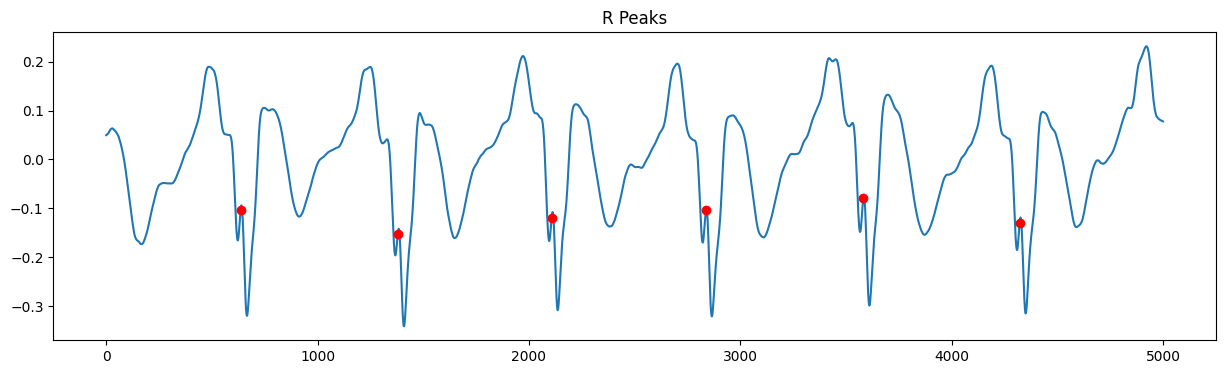

In [6]:
plt.figure(figsize=(15,4))

plt.plot(cleaned[:5000])

plt.plot(
    r_peaks[r_peaks < 5000],
    cleaned[r_peaks[r_peaks < 5000]],
    "ro"
)

plt.title("R Peaks")

plt.show()

In [7]:
beats = []

window_before = 200
window_after = 400

In [8]:
for peak in r_peaks:

    start = peak - window_before
    end = peak + window_after

    # tránh out-of-bounds
    if start >= 0 and end < len(cleaned):

        beat = cleaned[start:end]

        beats.append(beat)

In [9]:
print(len(beats))

51


In [10]:
print(beats[0].shape)

(600,)


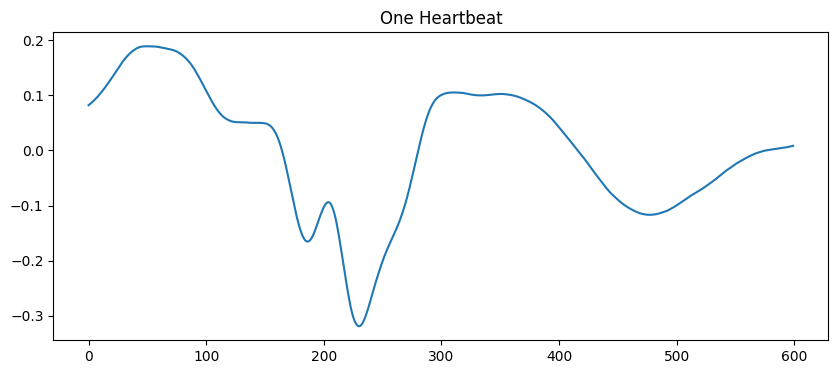

In [11]:
plt.figure(figsize=(10,4))

plt.plot(beats[0])

plt.title("One Heartbeat")

plt.show()

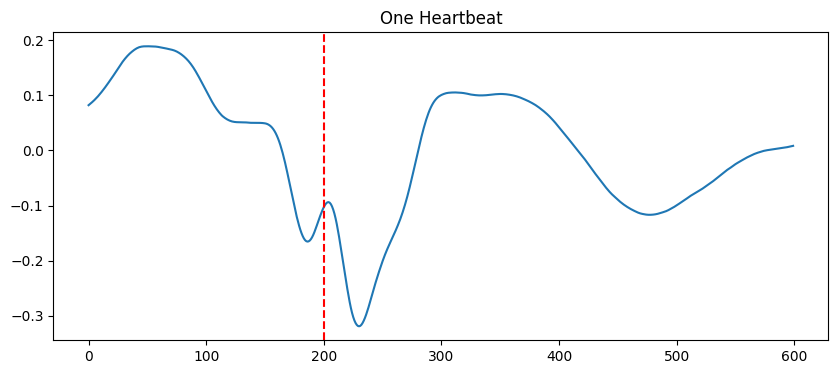

In [20]:
plt.figure(figsize=(10,4))

plt.plot(beats[0])

plt.axvline(
    x=200,
    color='red',
    linestyle='--'
)

plt.title("One Heartbeat")

plt.show()

In [12]:
def extract_features(beat):

    features = {}

    features["mean"] = np.mean(beat)

    features["std"] = np.std(beat)

    features["max"] = np.max(beat)

    features["min"] = np.min(beat)

    features["range"] = np.max(beat) - np.min(beat)

    features["rms"] = np.sqrt(np.mean(beat**2))

    return features

In [13]:
f = extract_features(beats[0])

print(f)

{'mean': np.float64(0.0017703656885255726), 'std': np.float64(0.119330621814192), 'max': np.float64(0.18936227417669635), 'min': np.float64(-0.319483289725136), 'range': np.float64(0.5088455639018323), 'rms': np.float64(0.11934375349063238)}


In [14]:
feature_list = []

for beat in beats:

    feature_list.append(
        extract_features(beat)
    )

In [15]:
df_features = pd.DataFrame(feature_list)

print(df_features.head())

       mean       std       max       min     range       rms
0  0.001770  0.119331  0.189362 -0.319483  0.508846  0.119344
1 -0.017632  0.126664  0.189066 -0.340970  0.530036  0.127885
2  0.000723  0.124616  0.211331 -0.308122  0.519453  0.124618
3 -0.017220  0.123472  0.195643 -0.320831  0.516474  0.124667
4  0.001503  0.130825  0.207092 -0.298624  0.505716  0.130834


In [16]:
label = "anterior"

df_features["label"] = label

In [17]:
rr_intervals = np.diff(r_peaks) / fs